<a href="https://colab.research.google.com/github/it25102877/IT2011-AIML-Project/blob/member-3-IT25102631/Copy_of_Untitled1n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# to search your entire Google Drive for the file
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "Movies_Reviews" in file or "movie" in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Movies_Reviews_modified_version1.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Movies_Reviews_modified_version1.csv")

In [ ]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.columns.tolist())
df.head(3)

Dataset loaded successfully!
Shape: (46173, 8)
['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion']


,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

sns.set(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
print("First 10 values of the 'genres' column:")
print(df['genres'].head(10))

print("\nData type of genres column:", df['genres'].dtype)
print("\nTotal rows:", len(df))

First 10 values of the 'genres' column:
0    ['Comedy', 'Drama', 'Romance']
1    ['Comedy', 'Drama', 'Romance']
2    ['Comedy', 'Drama', 'Romance']
3    ['Comedy', 'Drama', 'Romance']
4    ['Comedy', 'Drama', 'Romance']
5    ['Comedy', 'Drama', 'Romance']
6    ['Comedy', 'Drama', 'Romance']
7    ['Comedy', 'Drama', 'Romance']
8                        ['Comedy']
9                        ['Comedy']
Name: genres, dtype: object

Data type of genres column: object

Total rows: 46173


In [ ]:
# Parsing the stringified lists using ast.literal_eval
def parse_genres(x):
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)
        else:
            return []
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)

print("Parsing completed!")
print("\nSample after parsing:")
print(df[['genres', 'genres_list']].head(8))

Parsing completed!

Sample after parsing:
                           genres               genres_list
0  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
1  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
2  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
3  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
4  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
5  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
6  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]
7  ['Comedy', 'Drama', 'Romance']  [Comedy, Drama, Romance]


In [ ]:
# Applying MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genres_list'])

# Create DataFrame with binary columns
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index)

# Add prefix for clarity
genre_df = genre_df.add_prefix('genre_')

print("MultiLabelBinarizer applied successfully!")
print("\nNumber of unique genres found:", len(mlb.classes_))
print("\nEncoded genre columns:")
print(genre_df.columns.tolist())
print("\nShape of encoded matrix:", genre_df.shape)

print("\nFirst 5 rows of encoded genres:")
display(genre_df.head())

MultiLabelBinarizer applied successfully!

Number of unique genres found: 20

Encoded genre columns:
['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']

Shape of encoded matrix: (46173, 20)

First 5 rows of encoded genres:


,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_Foreign,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


In [ ]:
df_encoded = pd.concat([df, genre_df], axis=1)

print("Final shape after adding encoded genres:", df_encoded.shape)
print("\nNew columns added successfully!")

Final shape after adding encoded genres: (46173, 29)

New columns added successfully!


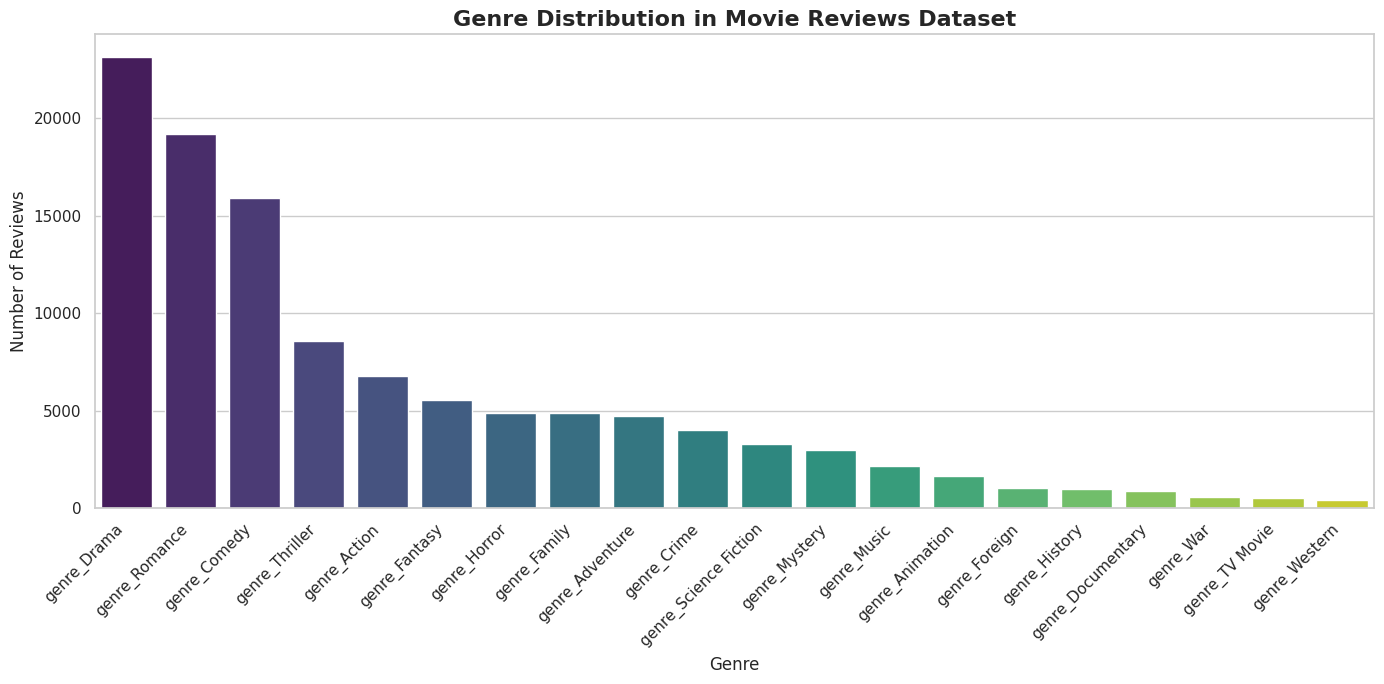


Top 10 most common genres:
genre_Drama        23136
genre_Romance      19184
genre_Comedy       15909
genre_Thriller      8599
genre_Action        6803
genre_Fantasy       5558
genre_Horror        4887
genre_Family        4880
genre_Adventure     4750
genre_Crime         3994
dtype: int64


In [ ]:
# Calculate frequency of each genre
genre_counts = genre_df.sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.title("Genre Distribution in Movie Reviews Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 most common genres:")
print(genre_counts.head(10))

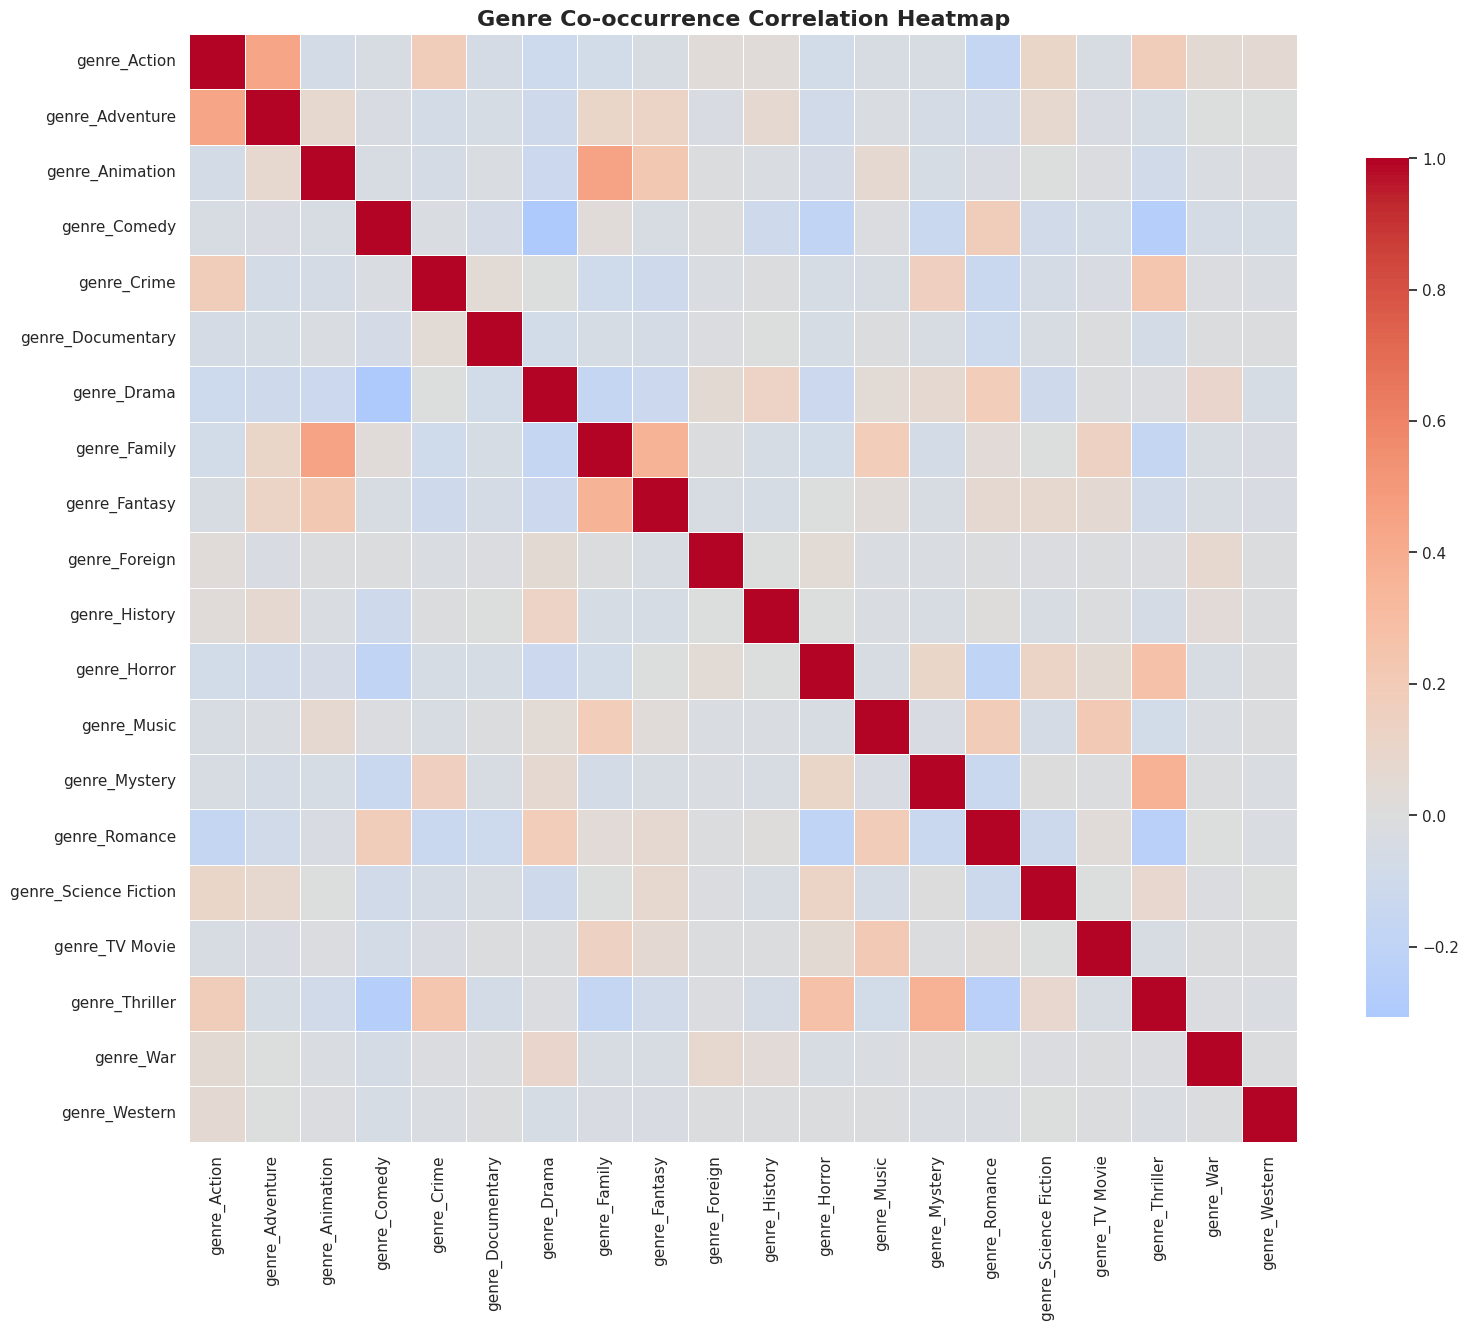

In [ ]:
# Correlation between genres (how often they appear together)
genre_corr = genre_df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(genre_corr,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.4,
            cbar_kws={"shrink": 0.7})
plt.title("Genre Co-occurrence Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

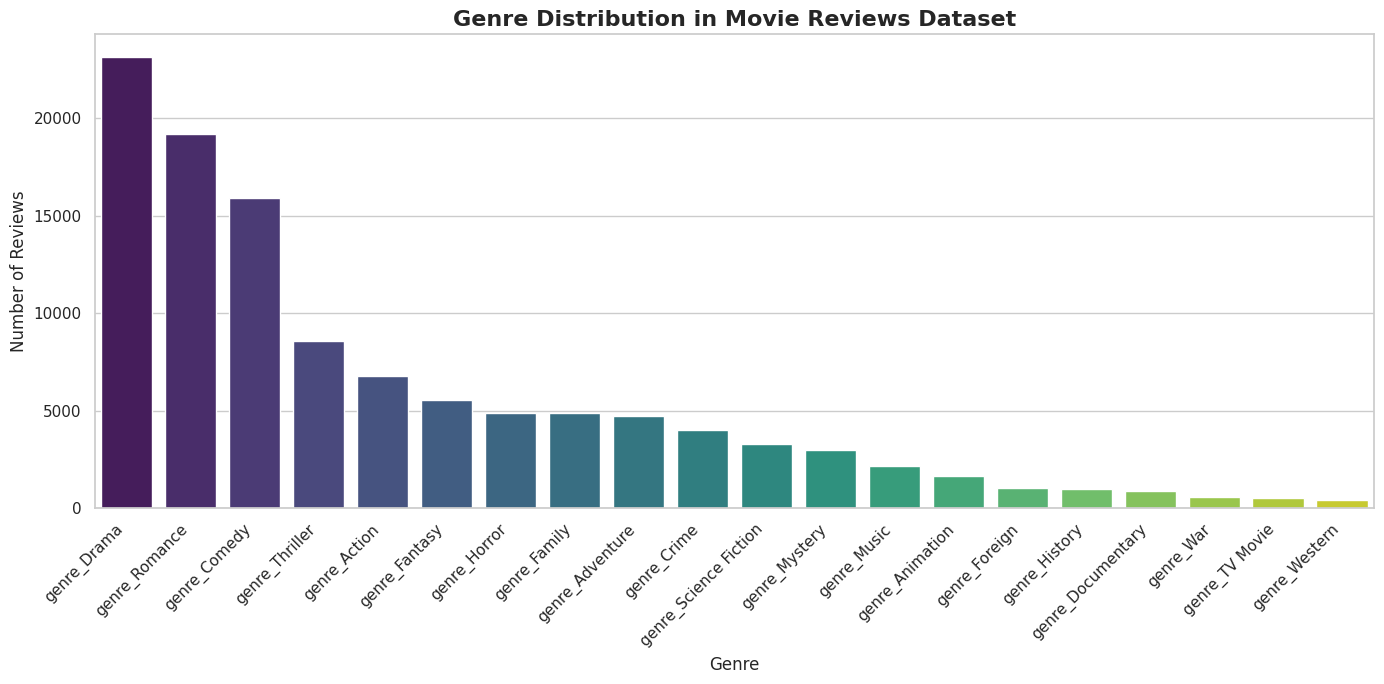

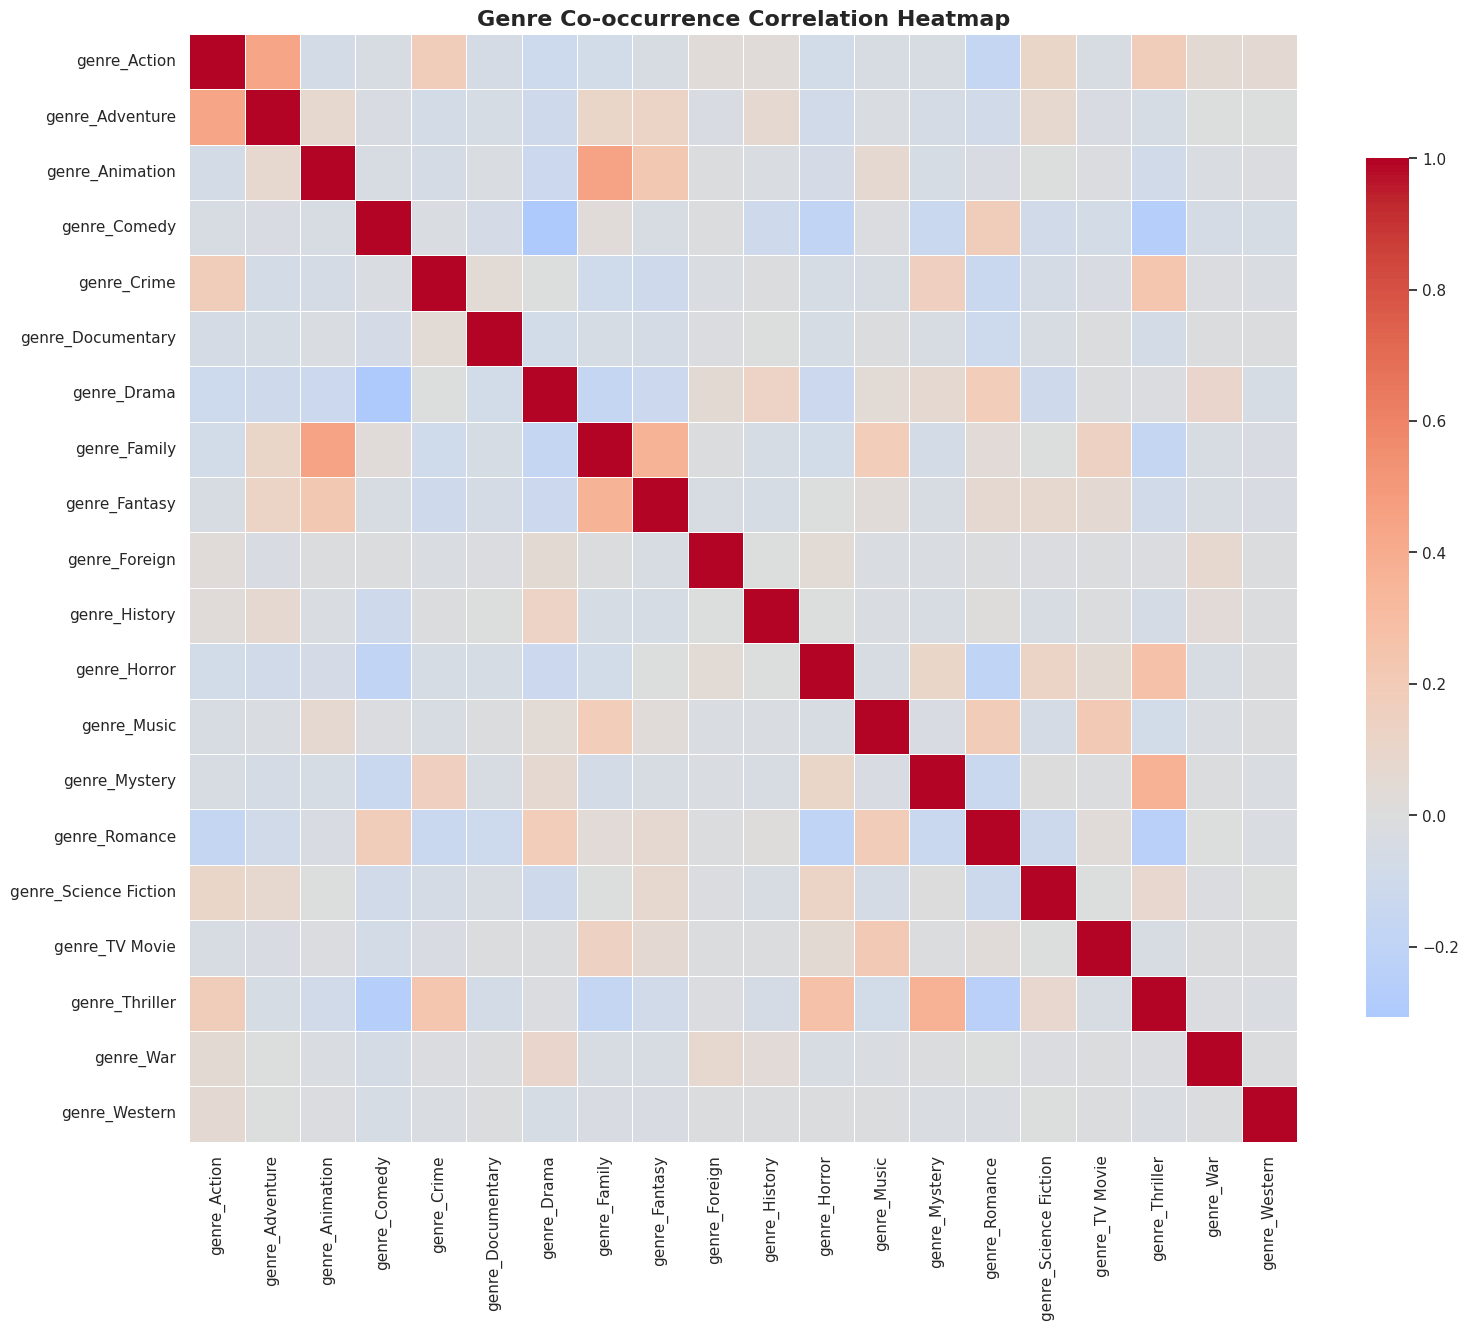

Both plots have been saved successfully!


In [ ]:
# Save Genre Distribution plot
plt.figure(figsize=(14, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.title("Genre Distribution in Movie Reviews Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("member3_genre_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Save Co-occurrence Heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(genre_corr, cmap='coolwarm', center=0, square=True, linewidths=0.4, cbar_kws={"shrink": 0.7})
plt.title("Genre Co-occurrence Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("member3_genre_cooccurrence_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("Both plots have been saved successfully!")